In [1]:
%pip install pillow numpy matplotlib pandas scipy h5py

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os
import scipy.io

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
base_dir = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers/RS_03948932"
marker = "CD44"
image_dir = os.path.join(base_dir, marker, "images")
mask_dir  = os.path.join(base_dir, marker, "masks")

mat_path = os.path.join(image_dir, "patch_000001.mat")

with h5py.File(mat_path, 'r') as f:
    print("Keys in .mat file:", list(f.keys()))

with h5py.File(mat_path, 'r') as f:
    img = f['patch_15_chw'][:]  # load as numpy array

print("Image shape:", img.shape)
print("dtype:", img.dtype)
print("min/max:", img.min(), img.max())

df = pd.read_csv(os.path.join(base_dir, marker, f"RS_03948932_{marker}_unet_patch_metadata.csv"))
print(df.head())
print(df.columns.tolist())

# load mask
mask_path = os.path.join(mask_dir, "patch_000001.png")
mask = np.array(Image.open(mask_path))

print("Mask shape:", mask.shape)
print("Unique mask values:", np.unique(mask))
print("Class counts:", {v: int((mask == v).sum()) for v in np.unique(mask)})

# visualize all 15 channels + mask
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
axes = axes.flatten()

for i in range(15):
    axes[i].imshow(img[:, :, i], cmap='gray')
    axes[i].set_title(f"Channel {i}")
    axes[i].axis('off')

# last plot = mask
axes[15].imshow(mask, cmap='tab10')
axes[15].set_title("GT Mask")
axes[15].axis('off')

plt.tight_layout()
plt.savefig("patch_visualization.png", dpi=150)
plt.show()
print("Saved to patch_visualization.png")

NameError: name 'h5py' is not defined

In [3]:
# find a patch that has all 3 class labels
df = pd.read_csv(os.path.join(base_dir, marker, f"RS_03948932_{marker}_unet_patch_metadata.csv"))

for patch_name in df['PatchName']:
    mask_path = os.path.join(mask_dir, f"{patch_name}.png")
    mask = np.array(Image.open(mask_path))
    unique_vals = np.unique(mask)
    if len(unique_vals) >= 3:
        print(f"Found patch with {len(unique_vals)} classes: {patch_name}")
        print("Unique values:", unique_vals)
        break

Found patch with 4 classes: patch_000013
Unique values: [0 1 2 3]


In [4]:
# load the informative patch
mat_path  = os.path.join(image_dir, "patch_000013.mat")
mask_path = os.path.join(mask_dir,  "patch_000013.png")

with h5py.File(mat_path, 'r') as f:
    img = f['patch_15_chw'][:]

mask = np.array(Image.open(mask_path))

# show a few key channels + mask side by side
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(img[:, :, 0], cmap='gray')
axes[0].set_title("Channel 0")
axes[0].axis('off')

axes[1].imshow(img[:, :, 2], cmap='gray')
axes[1].set_title("Channel 2")
axes[1].axis('off')

axes[2].imshow(img[:, :, 14], cmap='gray')
axes[2].set_title("Channel 14 (likely CD44)")
axes[2].axis('off')

# mask with labeled colorbar
im = axes[3].imshow(mask, cmap='tab10', vmin=0, vmax=3)
axes[3].set_title("GT Mask (all classes)")
axes[3].axis('off')
plt.colorbar(im, ax=axes[3], ticks=[0,1,2,3])

# overlay channel 14 with mask contour
axes[4].imshow(img[:, :, 14], cmap='gray')
axes[4].imshow(mask, cmap='tab10', alpha=0.4, vmin=0, vmax=3)
axes[4].set_title("Channel 14 + Mask Overlay")
axes[4].axis('off')

plt.tight_layout()
plt.savefig("patch_000013_visualization.png", dpi=150)
plt.show()

print("Class counts:", {v: int((mask == v).sum()) for v in np.unique(mask)})

NameError: name 'h5py' is not defined

In [21]:
import os, glob
import numpy as np
from PIL import Image

data_root = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"
counts = {0: 0, 1: 0, 2: 0, 3: 0}

mask_files = glob.glob(os.path.join(data_root, "*/CD44/masks/*.png"))
for mp in mask_files:
    mask = np.array(Image.open(mp))
    for v in [0, 1, 2, 3]:
        counts[v] += int((mask == v).sum())

total = sum(counts.values())
print("Global class counts:")
for v, c in counts.items():
    print(f"  class {v}: {c:>12,}  ({100*c/total:.1f}%)")

mask_files = glob.glob(os.path.join(data_root, "*/CD44/masks/*.png"))
mp = mask_files[0]
mask = np.array(Image.open(mp))
print("Raw mask unique values:", np.unique(mask))

for mp in mask_files:
    mask = np.array(Image.open(mp))
    unique = np.unique(mask)
    if len(unique) == 4:
        print("Found:", mp)
        print("Unique values:", unique)
        break

Global class counts:
  class 0:   98,043,813  (85.5%)
  class 1:    7,149,249  (6.2%)
  class 2:    7,416,542  (6.5%)
  class 3:    2,078,396  (1.8%)
Raw mask unique values: [0 3]
Found: /u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers/RS_03948932/CD44/masks/patch_000013.png
Unique values: [0 1 2 3]


In [22]:
import glob
import numpy as np
from PIL import Image

data_root = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"

val_patients = ["RS_03948956", "RS_03948980", "RS_03949016", "RS_03949046"]

counts = {0:0, 1:0, 2:0, 3:0}
for patient in val_patients:
    mask_files = glob.glob(f"{data_root}/{patient}/CD44/masks/*.png")
    for mp in mask_files:
        mask = np.array(Image.open(mp))
        for v in [0,1,2,3]:
            counts[v] += int((mask==v).sum())

total = sum(counts.values())
print("Val set class counts:")
for v,c in counts.items():
    print(f"  class {v}: {c:>10,}  ({100*c/total:.2f}%)")

Val set class counts:
  class 0: 34,475,642  (92.62%)
  class 1:  2,115,941  (5.68%)
  class 2:    632,865  (1.70%)
  class 3:          0  (0.00%)


In [23]:
data_root = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"

all_patients = [
    "RS_03948932", "RS_03948938", "RS_03948956", "RS_03948968",
    "RS_03948980", "RS_03948992", "RS_03949004", "RS_03949010",
    "RS_03949016", "RS_03949022", "RS_03949028", "RS_03949046",
    "RS_03949058", "RS_03949070", "RS_03949094",
    "RS_extra_HN-C-00044-7", "RS_extra_HN-C-00083-4"
]

print("Class 3 pixel counts per patient:")
for patient in all_patients:
    mask_files = glob.glob(f"{data_root}/{patient}/CD44/masks/*.png")
    count = 0
    for mp in mask_files:
        mask = np.array(Image.open(mp))
        count += int((mask == 3).sum())
    print(f"  {patient}: {count:>10,}")

Class 3 pixel counts per patient:
  RS_03948932:  1,559,960
  RS_03948938:          0
  RS_03948956:          0
  RS_03948968:          0
  RS_03948980:          0
  RS_03948992:          0
  RS_03949004:          0
  RS_03949010:          0
  RS_03949016:          0
  RS_03949022:          0
  RS_03949028:          0
  RS_03949046:          0
  RS_03949058:    518,436
  RS_03949070:          0
  RS_03949094:          0
  RS_extra_HN-C-00044-7:          0
  RS_extra_HN-C-00083-4:          0


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Model loaded from /u/aayyah3/oral-biomarker-segmentation/outputs/channel13/best_model.pth
  Loaded 112 patches from 4 patients
Val patches: 112


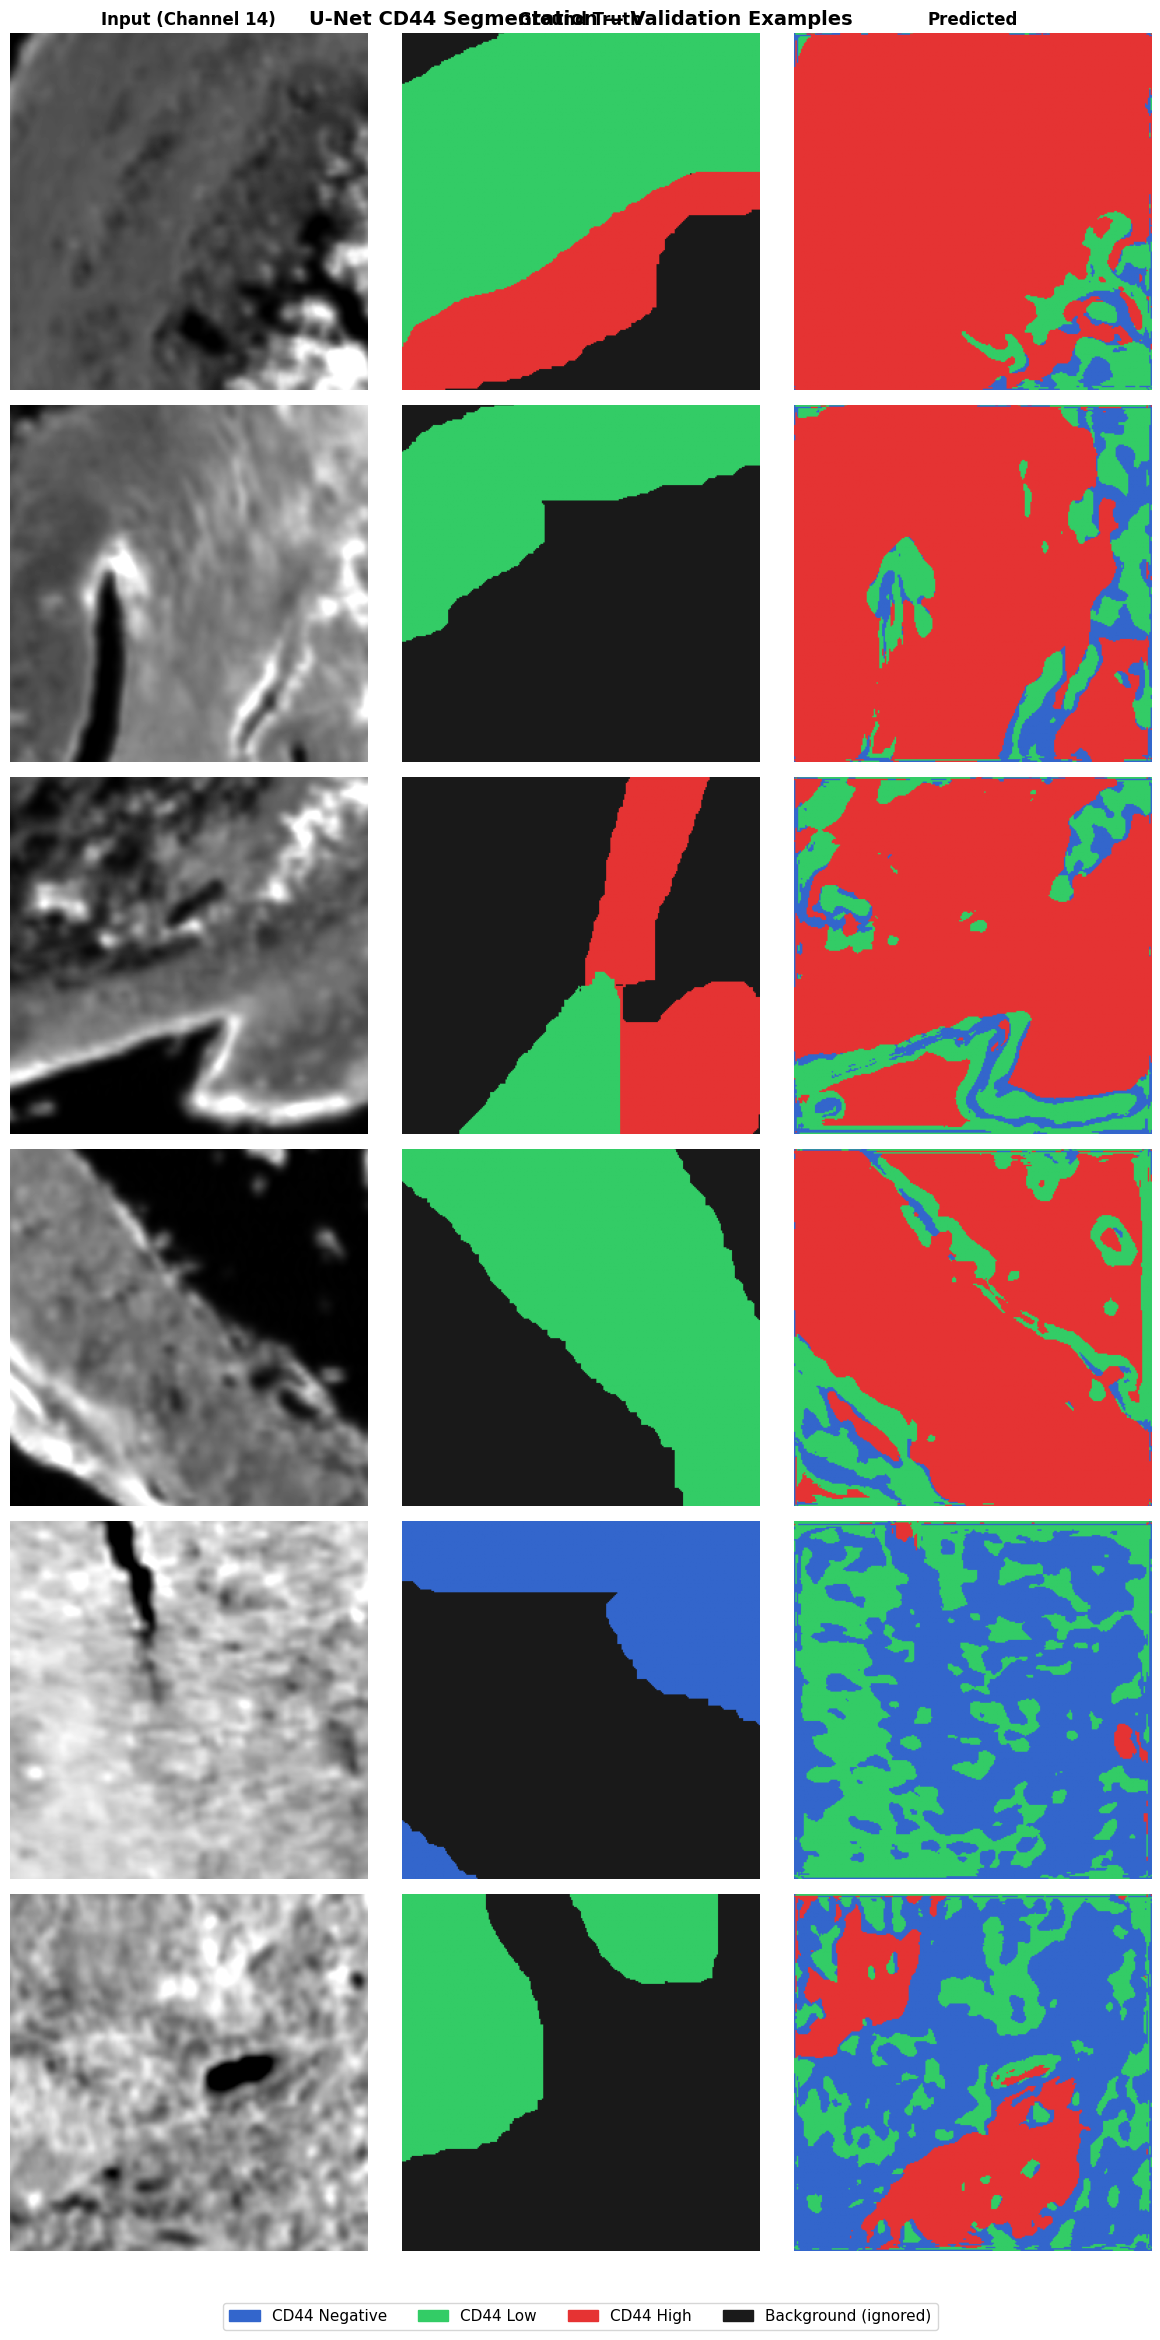

Saved to outputs/prediction_examples.png


In [6]:
%pip install torchvision
import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch

sys.path.append("/u/aayyah3/oral-biomarker-segmentation/src")
from model import UNet
from dataset import CD44Dataset, VAL_PATIENTS

# ── config ──
EXPERIMENT = "channel13"  # match what you set in train.py
MODEL_PATH = f"/u/aayyah3/oral-biomarker-segmentation/outputs/{EXPERIMENT}/best_model.pth"
SAVE_PATH  = f"/u/aayyah3/oral-biomarker-segmentation/outputs/{EXPERIMENT}/predictions.png"
DATA_ROOT  = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"
#MODEL_PATH = "/u/aayyah3/oral-biomarker-segmentation/outputs/best_model.pth"
NUM_EXAMPLES = 6

# ── load model ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = UNet(in_channels=1, num_classes=3).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f"Model loaded from {MODEL_PATH}")

# ── load val dataset ──
val_ds = CD44Dataset(DATA_ROOT, VAL_PATIENTS, augment=False)
print(f"Val patches: {len(val_ds)}")

# ── colormap and legend ──
# remapped labels: 0=negative, 1=low, 2=high
COLORS = {
    0: [0.2, 0.4, 0.8],   # blue  — CD44 negative
    1: [0.2, 0.8, 0.4],   # green — CD44 low
    2: [0.9, 0.2, 0.2],   # red   — CD44 high
}
IGNORE = 255

def mask_to_rgb(mask_np):
    """Convert label mask to RGB image for display."""
    rgb = np.ones((*mask_np.shape, 3), dtype=float) * 0.15  # dark bg
    for label, color in COLORS.items():
        rgb[mask_np == label] = color
    rgb[mask_np == IGNORE] = [0.1, 0.1, 0.1]   # background = near black
    return rgb

# ── pick evenly spaced examples from val set ──
indices = np.linspace(0, len(val_ds) - 1, NUM_EXAMPLES, dtype=int)

fig, axes = plt.subplots(NUM_EXAMPLES, 3, figsize=(12, NUM_EXAMPLES * 4))
fig.suptitle("U-Net CD44 Segmentation — Validation Examples", fontsize=14, fontweight='bold')

col_titles = ["Input (Channel 14)", "Ground Truth", "Predicted"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

# for row, idx in enumerate(indices):
#     img, mask = val_ds[idx]

#     # inference
#     with torch.no_grad():
#         logits = model(img.unsqueeze(0).to(device))   # (1,3,256,256)
#         pred   = logits.argmax(dim=1).squeeze(0).cpu().numpy()  # (256,256)

#     img_np  = img.squeeze(0).numpy()    # (256,256)
#     mask_np = mask.numpy()              # (256,256)

#     # input
#     axes[row, 0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
#     axes[row, 0].axis('off')

#     # ground truth
#     axes[row, 1].imshow(mask_to_rgb(mask_np))
#     axes[row, 1].axis('off')

#     # prediction
#     axes[row, 2].imshow(mask_to_rgb(pred))
#     axes[row, 2].axis('off')
for row, idx in enumerate(indices):
    mat_path, mask_path = val_ds.samples[idx]
    img, mask = val_ds[idx]

    # load RAW mask directly from file (before remapping)
    raw_mask = np.array(Image.open(mask_path))

    # convert raw mask to display colors
    # raw values: 0=background, 1=negative, 2=low, 3=high
    RAW_COLORS = {
        0: [0.1, 0.1, 0.1],   # black — background
        1: [0.2, 0.4, 0.8],   # blue  — CD44 negative
        2: [0.2, 0.8, 0.4],   # green — CD44 low
        3: [0.9, 0.2, 0.2],   # red   — CD44 high
    }

    def raw_mask_to_rgb(mask_np):
        rgb = np.zeros((*mask_np.shape, 3), dtype=float)
        for label, color in RAW_COLORS.items():
            rgb[mask_np == label] = color
        return rgb

    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))
        pred   = logits.argmax(dim=1).squeeze(0).cpu().numpy()

     
    img_np = img.squeeze(0).numpy()
    mask_np = mask.numpy()

    # input
    axes[row, 0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].axis('off')

    # ground truth — use RAW mask
    axes[row, 1].imshow(raw_mask_to_rgb(raw_mask))
    axes[row, 1].axis('off')

    # prediction — use remapped mask
    axes[row, 2].imshow(mask_to_rgb(pred))
    axes[row, 2].axis('off')
# legend
legend_patches = [
    mpatches.Patch(color=COLORS[0], label='CD44 Negative'),
    mpatches.Patch(color=COLORS[1], label='CD44 Low'),
    mpatches.Patch(color=COLORS[2], label='CD44 High'),
    mpatches.Patch(color=[0.1,0.1,0.1], label='Background (ignored)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=11,
           bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight')
#plt.savefig("/u/aayyah3/oral-biomarker-segmentation/outputs/prediction_examples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/prediction_examples.png")

Raw mask unique values: [0 1 2 3]
Raw mask class counts: {np.uint8(0): 10294, np.uint8(1): 2964, np.uint8(2): 486, np.uint8(3): 51792}
       PatchName   SampleName   X1   Y1    X2    Y2  TissueFraction  \
12  patch_000013  RS_03948932  769  769  1024  1024        0.977951   

    LabelPixels Biomarker    MaskMode  
12        55242      CD44  multiclass  


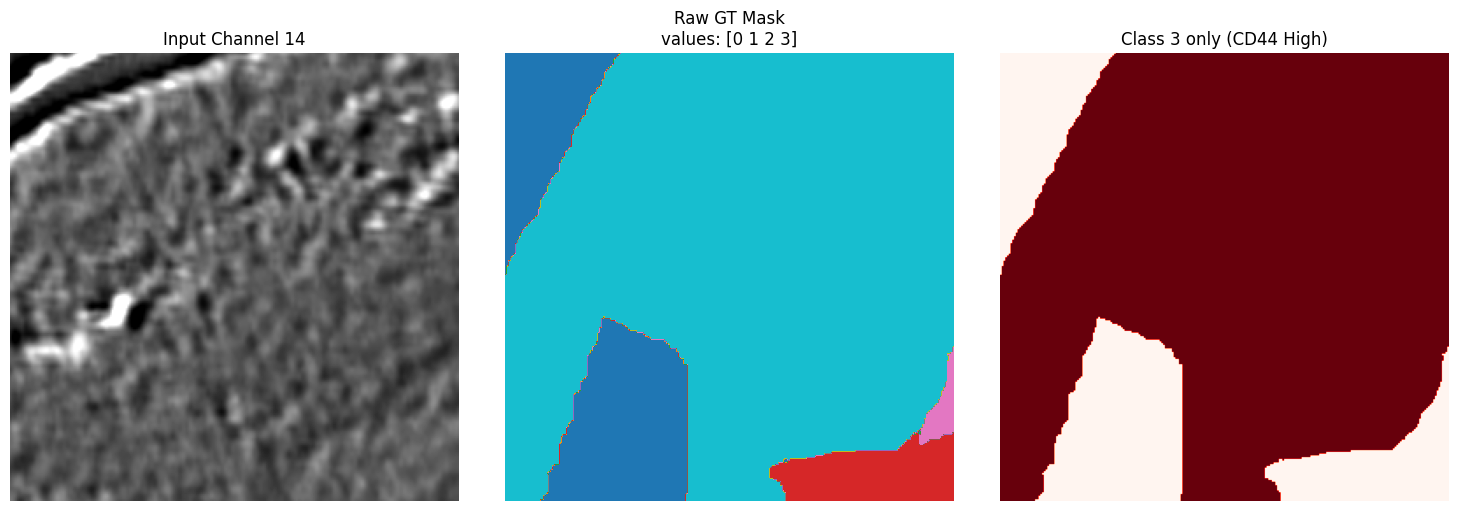

In [3]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import h5py

DATA_ROOT = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"

# pick one specific patch we know has all classes
mat_path  = f"{DATA_ROOT}/RS_03948932/CD44/images/patch_000013.mat"
mask_path = f"{DATA_ROOT}/RS_03948932/CD44/masks/patch_000013.png"

# load raw image channel 14
with h5py.File(mat_path, 'r') as f:
    img = f['patch_15_chw'][:, :, 14]

# load raw mask — NO remapping
raw_mask = np.array(Image.open(mask_path))

print("Raw mask unique values:", np.unique(raw_mask))
print("Raw mask class counts:", {v: int((raw_mask==v).sum()) for v in np.unique(raw_mask)})

# plot side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Input Channel 14")
axes[0].axis('off')

axes[1].imshow(raw_mask, cmap='tab10', vmin=0, vmax=3)
axes[1].set_title(f"Raw GT Mask\nvalues: {np.unique(raw_mask)}")
axes[1].axis('off')

# also show what the CSV says about this patch
import pandas as pd
csv_path = f"{DATA_ROOT}/RS_03948932/CD44/RS_03948932_CD44_unet_patch_metadata.csv"
df = pd.read_csv(csv_path)
print(df[df['PatchName'] == 'patch_000013'])

axes[2].imshow(raw_mask == 3, cmap='Reds')
axes[2].set_title("Class 3 only (CD44 High)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

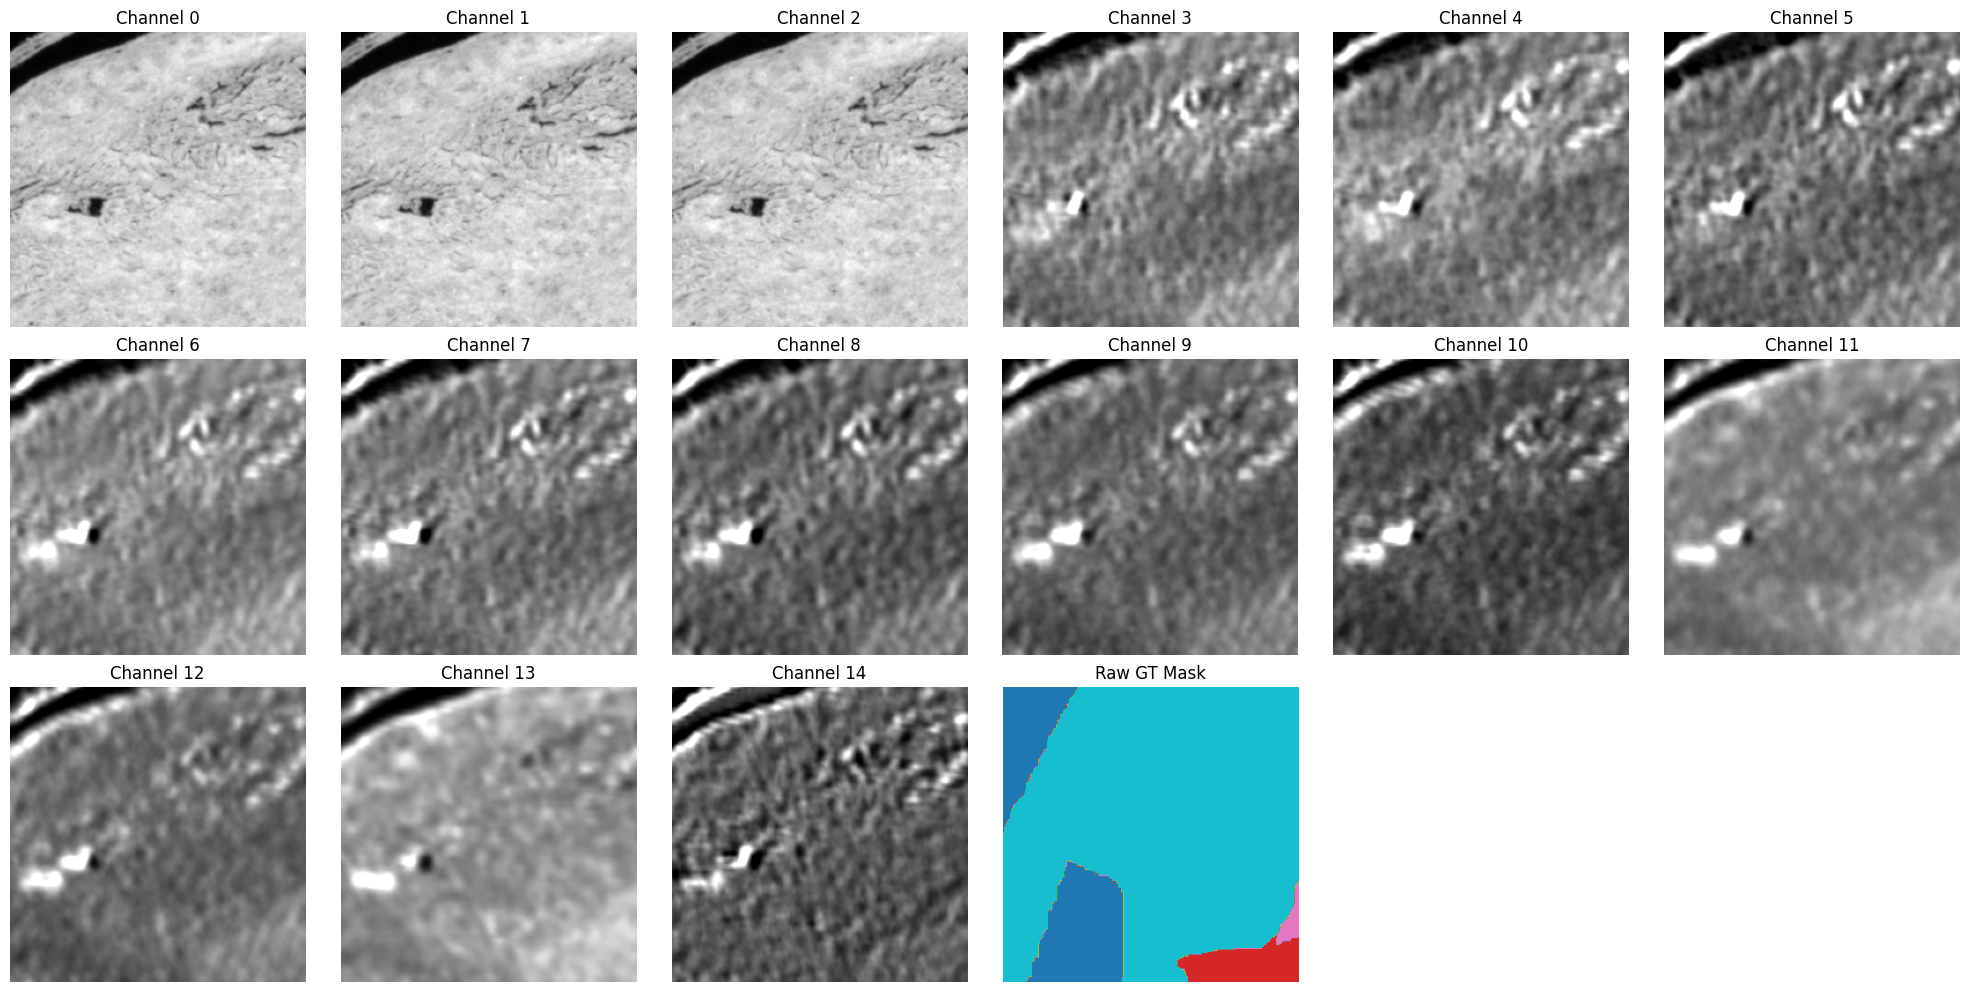

In [4]:
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()

with h5py.File(mat_path, 'r') as f:
    img_all = f['patch_15_chw'][:]

for i in range(15):
    axes[i].imshow(img_all[:, :, i], cmap='gray')
    axes[i].set_title(f"Channel {i}")
    axes[i].axis('off')

# show raw GT mask in last panel
axes[15].imshow(raw_mask, cmap='tab10', vmin=0, vmax=3)
axes[15].set_title("Raw GT Mask")
axes[15].axis('off')

# hide remaining panels
for i in range(16, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [5]:
with h5py.File(mat_path, 'r') as f:
    img_all = f['patch_15_chw'][:]

# for each channel, compute mean intensity in class 3 vs class 1 regions
class3_mask = raw_mask == 3
class1_mask = raw_mask == 1

print("Channel | Mean in Class3 | Mean in Class1 | Difference")
print("-" * 55)
for i in range(15):
    ch = img_all[:, :, i]
    m3 = ch[class3_mask].mean()
    m1 = ch[class1_mask].mean()
    print(f"  Ch {i:2d}  |    {m3:.4f}      |    {m1:.4f}      |  {m3-m1:+.4f}")

Channel | Mean in Class3 | Mean in Class1 | Difference
-------------------------------------------------------
  Ch  0  |    0.7389      |    0.7838      |  -0.0449
  Ch  1  |    0.7389      |    0.7838      |  -0.0449
  Ch  2  |    0.7389      |    0.7838      |  -0.0449
  Ch  3  |    0.5098      |    0.6153      |  -0.1055
  Ch  4  |    0.5186      |    0.6169      |  -0.0983
  Ch  5  |    0.4442      |    0.5412      |  -0.0970
  Ch  6  |    0.5278      |    0.6270      |  -0.0991
  Ch  7  |    0.4824      |    0.5913      |  -0.1088
  Ch  8  |    0.4087      |    0.4818      |  -0.0731
  Ch  9  |    0.4167      |    0.4949      |  -0.0782
  Ch 10  |    0.3428      |    0.3709      |  -0.0280
  Ch 11  |    0.5121      |    0.6460      |  -0.1338
  Ch 12  |    0.4422      |    0.5091      |  -0.0669
  Ch 13  |    0.6009      |    0.7534      |  -0.1526
  Ch 14  |    0.3678      |    0.3640      |  +0.0038


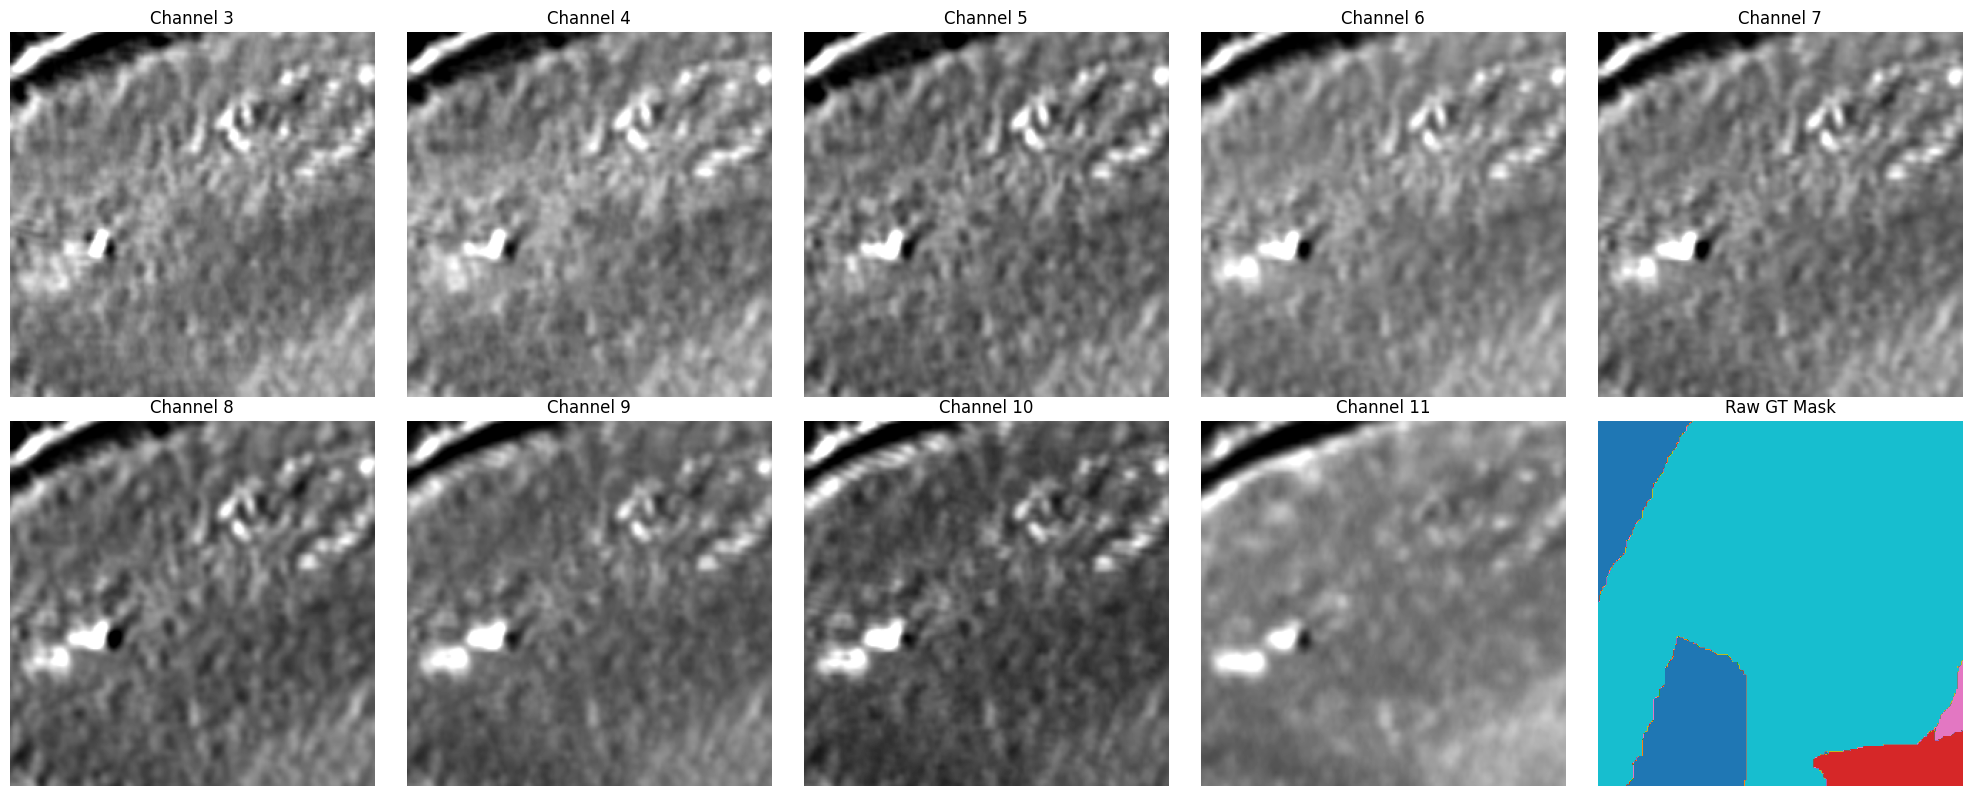

In [1]:
import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

DATA_ROOT = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"
mat_path  = f"{DATA_ROOT}/RS_03948932/CD44/images/patch_000013.mat"
mask_path = f"{DATA_ROOT}/RS_03948932/CD44/masks/patch_000013.png"

with h5py.File(mat_path, 'r') as f:
    img_all = f['patch_15_chw'][:]

raw_mask = np.array(Image.open(mask_path))

# check which channels look like dark field
# dark field = bright structures on dark background
# plot channels 3-11 side by side with mask
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

channels_to_check = [3, 4, 5, 6, 7, 8, 9, 10, 11]
for i, ch in enumerate(channels_to_check):
    axes[i].imshow(img_all[:, :, ch], cmap='gray')
    axes[i].set_title(f"Channel {ch}")
    axes[i].axis('off')

axes[9].imshow(raw_mask, cmap='tab10', vmin=0, vmax=3)
axes[9].set_title("Raw GT Mask")
axes[9].axis('off')

plt.tight_layout()
plt.show()

In [2]:
import h5py
import numpy as np

mat_path = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers/RS_03948932/CD44/images/patch_000013.mat"

with h5py.File(mat_path, 'r') as f:
    print("All keys:", list(f.keys()))
    for key in f.keys():
        item = f[key]
        print(f"\nKey: {key}")
        print(f"  Shape: {item.shape}")
        print(f"  Dtype: {item.dtype}")
        print(f"  Min: {item[()].min():.4f}")
        print(f"  Max: {item[()].max():.4f}")
        # check for attributes which might contain channel names
        if len(item.attrs) > 0:
            print(f"  Attributes: {dict(item.attrs)}")
    
    # also check file-level attributes
    print("\nFile attributes:", dict(f.attrs))

All keys: ['patch_15_chw']

Key: patch_15_chw
  Shape: (256, 256, 15)
  Dtype: float32
  Min: 0.0000
  Max: 1.0000
  Attributes: {'MATLAB_class': np.bytes_(b'single')}

File attributes: {}


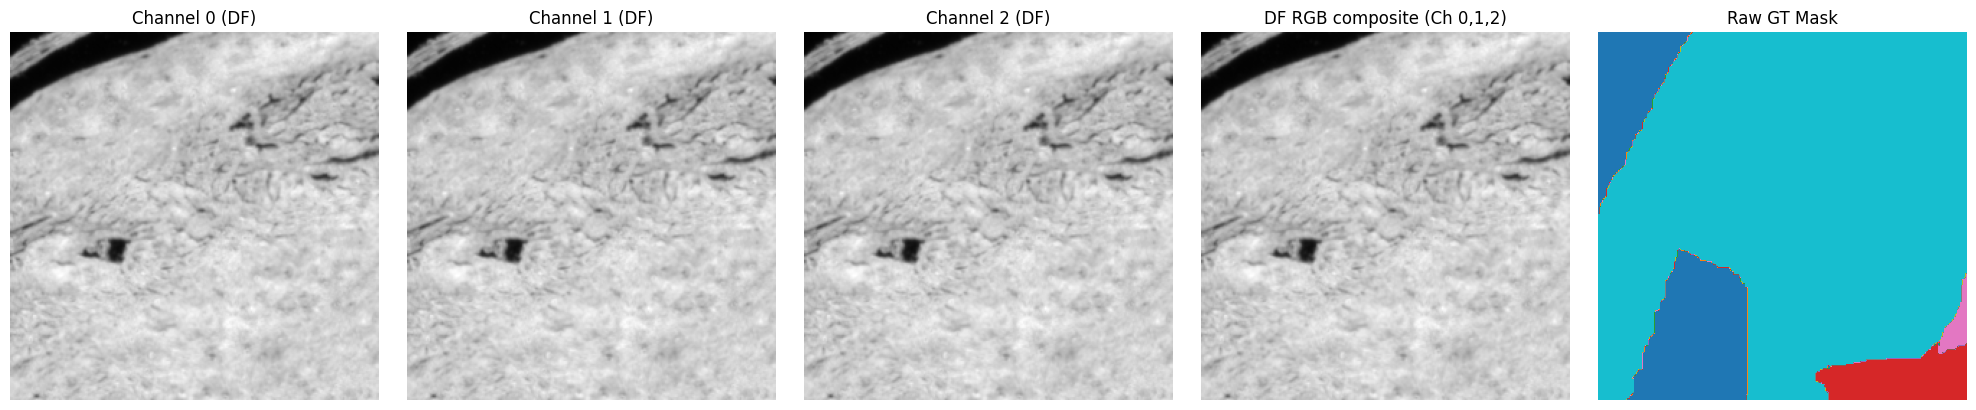

In [3]:
import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

DATA_ROOT = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"
mat_path  = f"{DATA_ROOT}/RS_03948932/CD44/images/patch_000013.mat"
mask_path = f"{DATA_ROOT}/RS_03948932/CD44/masks/patch_000013.png"

with h5py.File(mat_path, 'r') as f:
    img_all = f['patch_15_chw'][:]

raw_mask = np.array(Image.open(mask_path))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# DF channels 0, 1, 2
for i in range(3):
    axes[i].imshow(img_all[:, :, i], cmap='gray')
    axes[i].set_title(f"Channel {i} (DF)")
    axes[i].axis('off')

# RGB composite of channels 0,1,2
rgb = img_all[:, :, :3]
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
axes[3].imshow(rgb)
axes[3].set_title("DF RGB composite (Ch 0,1,2)")
axes[3].axis('off')

# GT mask
axes[4].imshow(raw_mask, cmap='tab10', vmin=0, vmax=3)
axes[4].set_title("Raw GT Mask")
axes[4].axis('off')

plt.tight_layout()
plt.show()

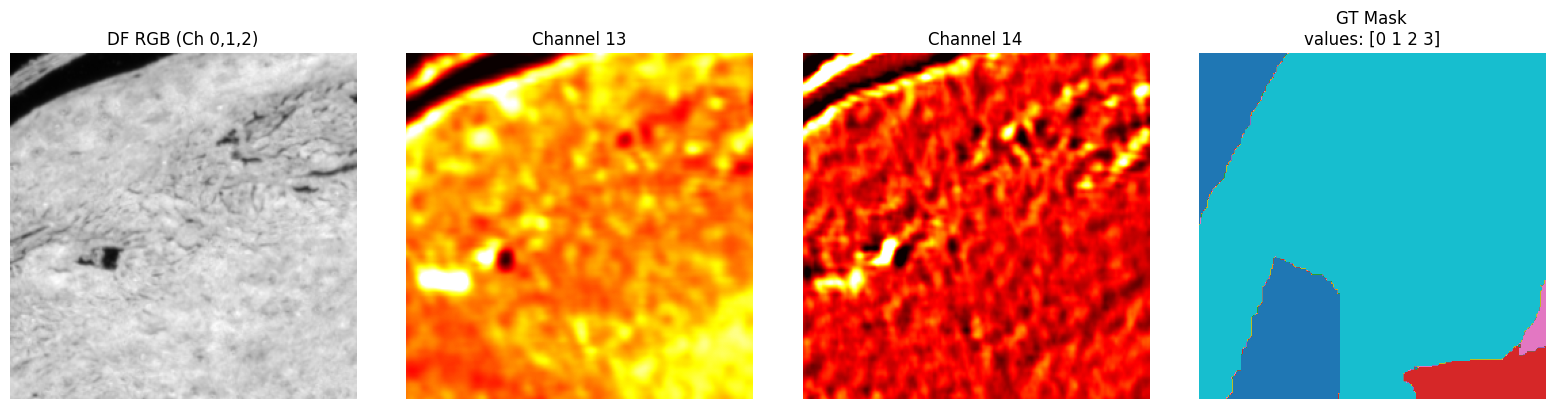

In [5]:
import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

best_patch_mask = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers/RS_03948932/CD44/masks/patch_000013.png"

# find the corresponding image
best_patch_img = best_patch_mask.replace("masks", "images").replace(".png", ".mat")

with h5py.File(best_patch_img, 'r') as f:
    img_all = f['patch_15_chw'][:]

raw_mask = np.array(Image.open(best_patch_mask))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# DF RGB composite
rgb = img_all[:, :, :3]
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
axes[0].imshow(rgb)
axes[0].set_title("DF RGB (Ch 0,1,2)")
axes[0].axis('off')

# channel 13 (possible marker)
axes[1].imshow(img_all[:, :, 13], cmap='hot')
axes[1].set_title("Channel 13")
axes[1].axis('off')

# channel 14
axes[2].imshow(img_all[:, :, 14], cmap='hot')
axes[2].set_title("Channel 14")
axes[2].axis('off')

# raw mask
axes[3].imshow(raw_mask, cmap='tab10', vmin=0, vmax=3)
axes[3].set_title(f"GT Mask\nvalues: {np.unique(raw_mask)}")
axes[3].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import os
import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import glob

DATA_ROOT = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"
ALL_PATIENTS = [
    "RS_03948932", "RS_03948938", "RS_03948956", "RS_03948968",
    "RS_03948980", "RS_03948992", "RS_03949004", "RS_03949010",
    "RS_03949016", "RS_03949022", "RS_03949028", "RS_03949046",
    "RS_03949058", "RS_03949070", "RS_03949094",
    "RS_extra_HN-C-00044-7", "RS_extra_HN-C-00083-4"
]

# collect all patches with tissue
all_pairs = []
for patient in ALL_PATIENTS:
    mask_files = sorted(glob.glob(f"{DATA_ROOT}/{patient}/CD44/masks/*.png"))
    for mask_path in mask_files:
        mask = np.array(Image.open(mask_path))
        if (mask != 0).sum() == 0:
            continue
        patch_name = os.path.basename(mask_path).replace(".png", "")
        img_path   = mask_path.replace("masks", "images").replace(".png", ".mat")
        if os.path.exists(img_path):
            all_pairs.append((img_path, mask_path, patient, patch_name))

print(f"Total patches with tissue: {len(all_pairs)}")

# save 20 patches per page
PATCHES_PER_PAGE = 20
out_dir = "/u/aayyah3/oral-biomarker-segmentation/outputs/gt_visualization"
os.makedirs(out_dir, exist_ok=True)

for page, start in enumerate(range(0, len(all_pairs), PATCHES_PER_PAGE)):
    batch = all_pairs[start:start + PATCHES_PER_PAGE]
    fig, axes = plt.subplots(len(batch), 2, figsize=(8, len(batch) * 4))
    if len(batch) == 1:
        axes = [axes]

    for row, (img_path, mask_path, patient, patch_name) in enumerate(batch):
        with h5py.File(img_path, 'r') as f:
            ch13 = f['patch_15_chw'][:, :, 13]
        raw_mask = np.array(Image.open(mask_path))

        axes[row][0].imshow(ch13, cmap='hot')
        axes[row][0].set_title(f"{patient} {patch_name}", fontsize=6)
        axes[row][0].axis('off')

        axes[row][1].imshow(raw_mask, cmap='tab10', vmin=0, vmax=3)
        axes[row][1].set_title(f"GT values: {np.unique(raw_mask)}", fontsize=6)
        axes[row][1].axis('off')

    save_path = os.path.join(out_dir, f"page_{page+1:03d}.png")
    plt.savefig(save_path, dpi=80, bbox_inches='tight')
    plt.close()
    print(f"Saved page {page+1}: patches {start+1}-{start+len(batch)}")

print(f"Done — saved to {out_dir}")


Total patches with tissue: 605
Saved page 1: patches 1-20
Saved page 2: patches 21-40
Saved page 3: patches 41-60
Saved page 4: patches 61-80
Saved page 5: patches 81-100
Saved page 6: patches 101-120
Saved page 7: patches 121-140
Saved page 8: patches 141-160
Saved page 9: patches 161-180
Saved page 10: patches 181-200
Saved page 11: patches 201-220
Saved page 12: patches 221-240
Saved page 13: patches 241-260
Saved page 14: patches 261-280
Saved page 15: patches 281-300
Saved page 16: patches 301-320
Saved page 17: patches 321-340
Saved page 18: patches 341-360
Saved page 19: patches 361-380
Saved page 20: patches 381-400
Saved page 21: patches 401-420
Saved page 22: patches 421-440
Saved page 23: patches 441-460
Saved page 24: patches 461-480
Saved page 25: patches 481-500
Saved page 26: patches 501-520
Saved page 27: patches 521-540
Saved page 28: patches 541-560
Saved page 29: patches 561-580
Saved page 30: patches 581-600
Saved page 31: patches 601-605
Done — saved to /u/aayyah3/

In [1]:
import h5py
import numpy as np
import glob

DATA_ROOT = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"
mat_files = sorted(glob.glob(f"{DATA_ROOT}/*/CD44/images/*.mat"))[:10]

for mat_path in mat_files:
    with h5py.File(mat_path, 'r') as f:
        raw = f['patch_15_chw'][:]
    print(f"{mat_path.split('/')[-3]} | {mat_path.split('/')[-1]} | shape: {raw.shape}")

CD44 | patch_000001.mat | shape: (256, 256, 15)
CD44 | patch_000002.mat | shape: (256, 256, 15)
CD44 | patch_000003.mat | shape: (256, 256, 15)
CD44 | patch_000004.mat | shape: (256, 256, 15)
CD44 | patch_000005.mat | shape: (256, 256, 15)
CD44 | patch_000006.mat | shape: (256, 256, 15)
CD44 | patch_000007.mat | shape: (256, 256, 15)
CD44 | patch_000008.mat | shape: (256, 256, 15)
CD44 | patch_000009.mat | shape: (256, 256, 15)
CD44 | patch_000010.mat | shape: (256, 256, 15)


Raw HDF5 shape: (256, 256, 15)
Corrected FTIR shape: (15, 256, 256)
Mask shape: (256, 256)
Mask values: [0 3]
Selected band shape: (256, 256)


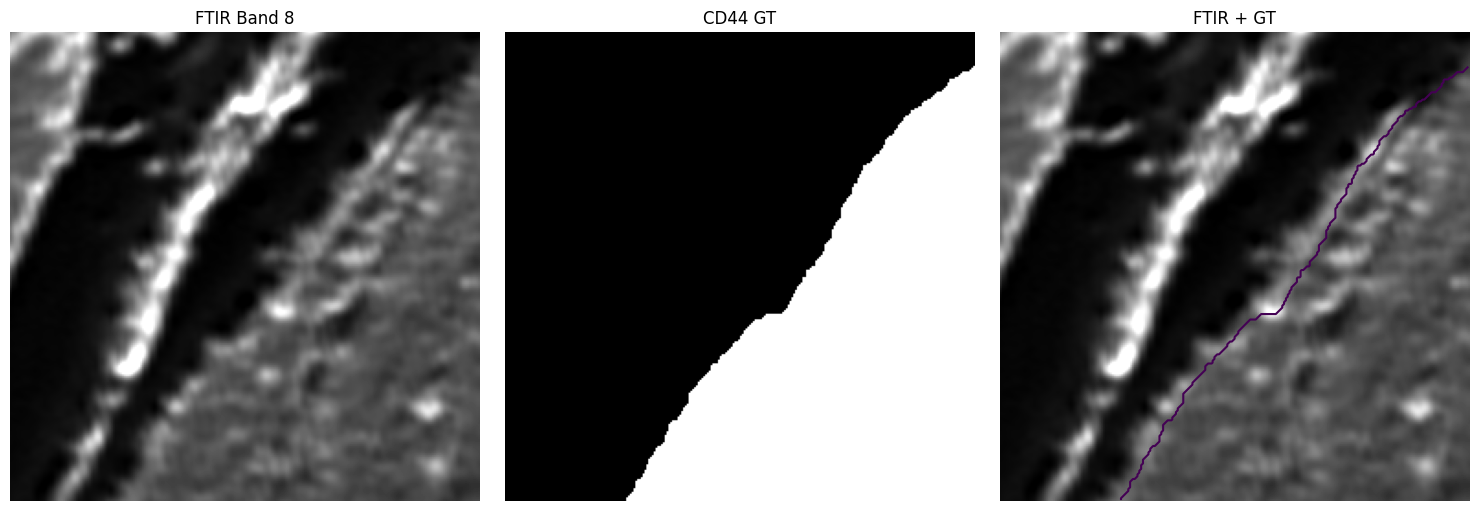

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

mat_path = r"/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers/RS_03948932/CD44/images/patch_000007.mat"

mask_path = r"/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers/RS_03948932/CD44/masks/patch_000007.png"



with h5py.File(mat_path, "r") as f:

    raw = np.array(f["patch_15_chw"])

print("Raw HDF5 shape:", raw.shape)




ftir = np.transpose(raw, (2, 1, 0))

print("Corrected FTIR shape:", ftir.shape)


mask = np.array(Image.open(mask_path))

if mask.ndim == 3:
    mask = mask[:, :, 0]

print("Mask shape:", mask.shape)
print("Mask values:", np.unique(mask))

cd44_mask = mask == 3



band_idx = 8

img = ftir[band_idx - 1, :, :]

print("Selected band shape:", img.shape)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# FTIR
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"FTIR Band {band_idx}")
axes[0].axis("off")


# GT
axes[1].imshow(cd44_mask, cmap="gray")
axes[1].set_title("CD44 GT")
axes[1].axis("off")


# Overlay
axes[2].imshow(img, cmap="gray")

axes[2].contour(
    cd44_mask.astype(float),
    levels=[0.5],
    linewidths=1.5
)

axes[2].set_title("FTIR + GT")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Model loaded — device: cpu
  Loaded 112 patches from 4 patients
Val patches: 112


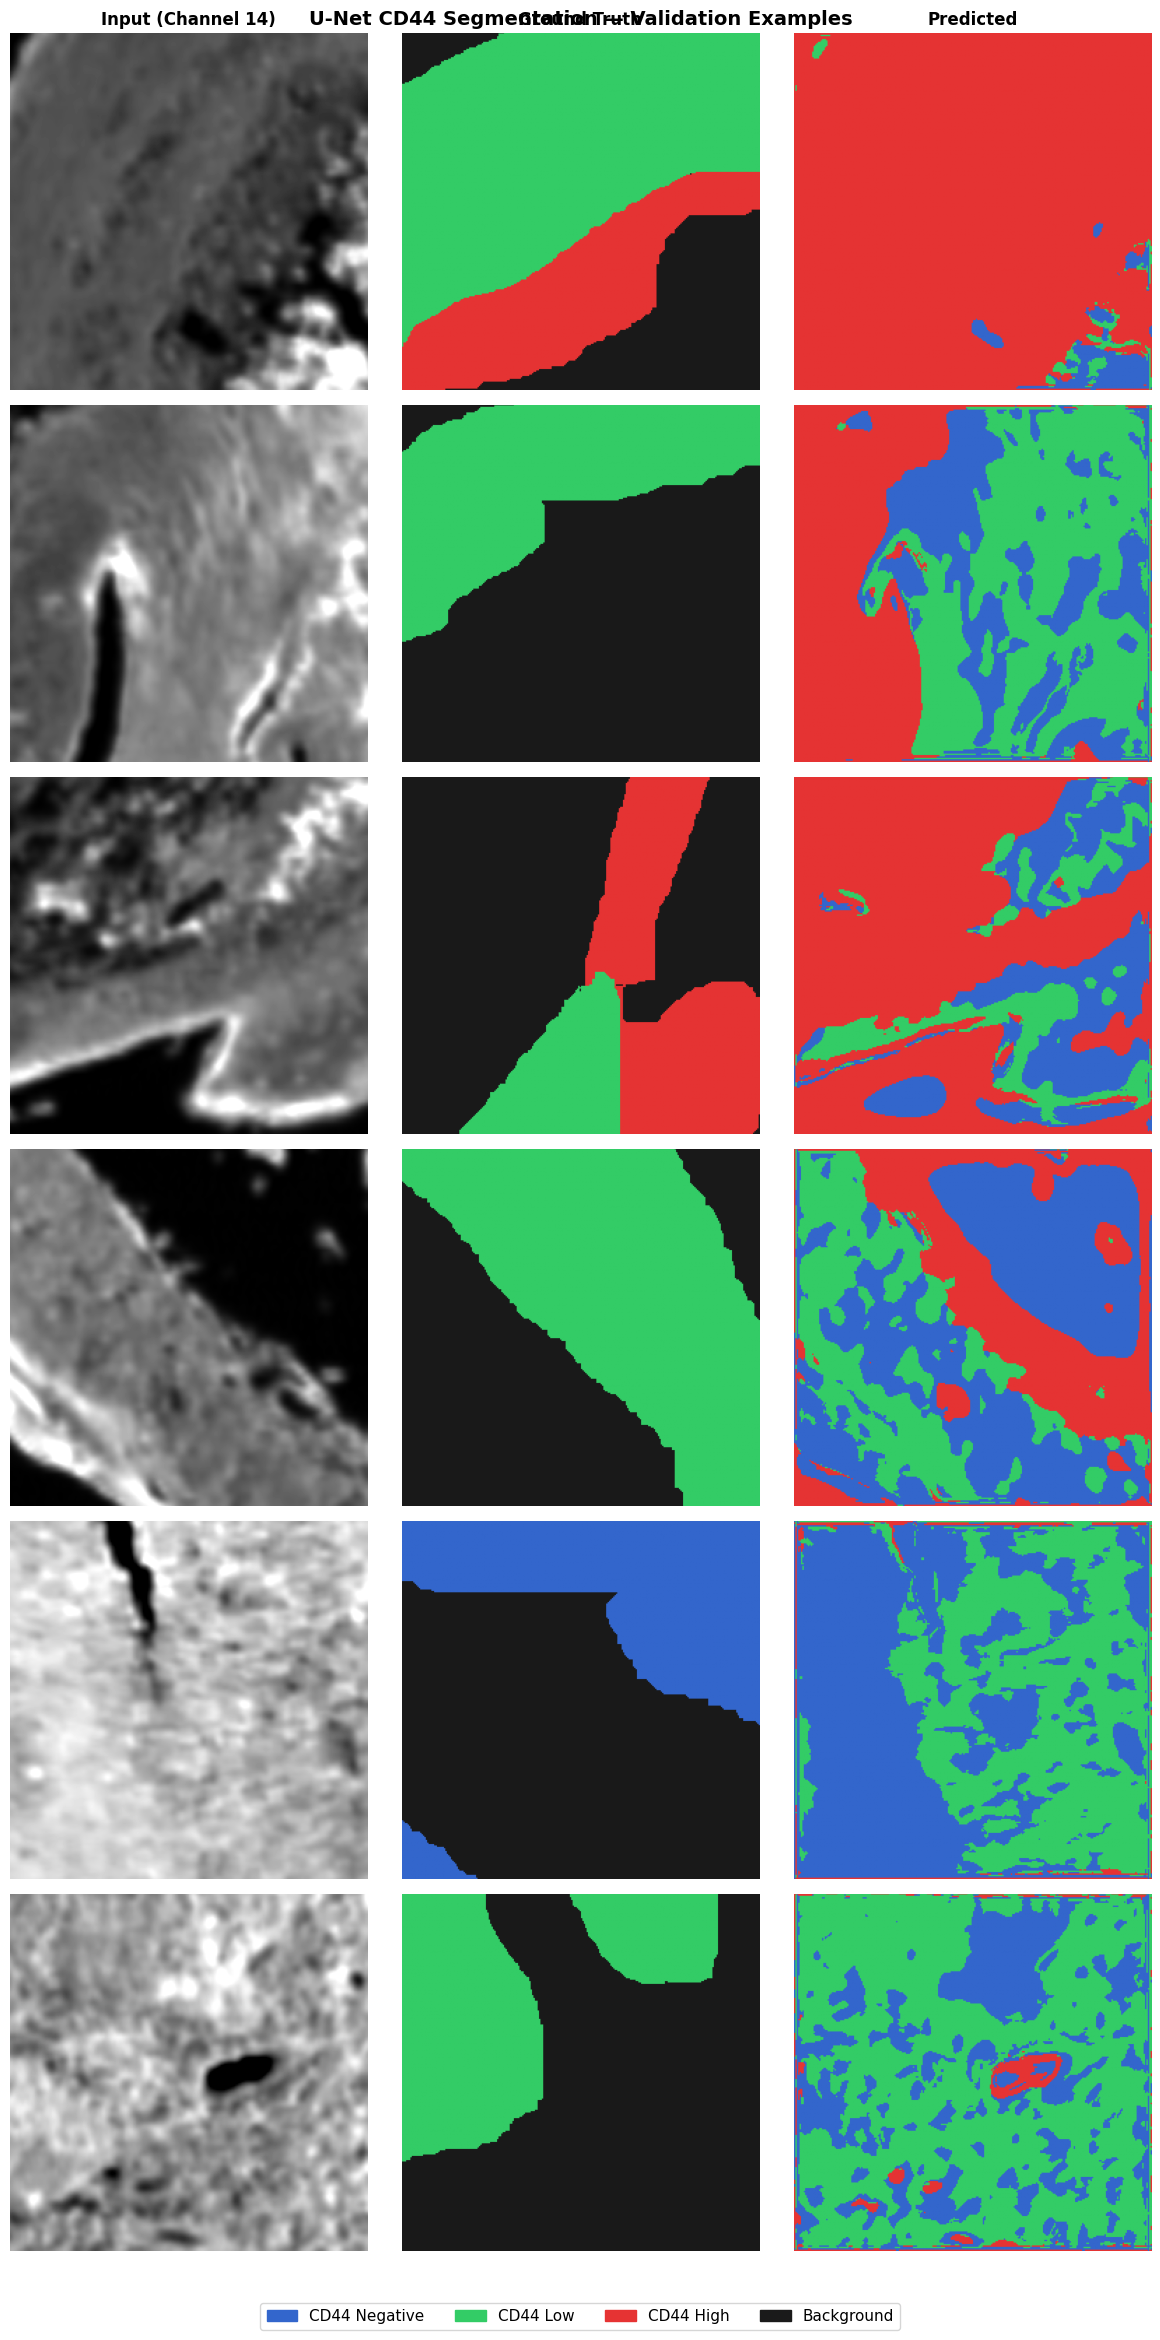

Saved to /u/aayyah3/oral-biomarker-segmentation/outputs/augmentation/predictions_fixed_gt.png


In [12]:
%pip install torchvision h5py

import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch

sys.path.append("/u/aayyah3/oral-biomarker-segmentation/src")
from model import UNet
from dataset import CD44Dataset, VAL_PATIENTS

# ── config ──
MODEL_PATH = "/u/aayyah3/oral-biomarker-segmentation/outputs/augmentation/best_model.pth"
SAVE_PATH  = "/u/aayyah3/oral-biomarker-segmentation/outputs/augmentation/predictions_fixed_gt.png"
DATA_ROOT  = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"
NUM_EXAMPLES = 6

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

# ── load model ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = UNet(in_channels=1, num_classes=3).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f"Model loaded — device: {device}")

# ── load val patches manually (bypass dataset __getitem__) ──
val_ds   = CD44Dataset(DATA_ROOT, VAL_PATIENTS, augment=False)
samples  = val_ds.samples
print(f"Val patches: {len(samples)}")

# ── colors ──
PRED_COLORS = {
    0: [0.2, 0.4, 0.8],
    1: [0.2, 0.8, 0.4],
    2: [0.9, 0.2, 0.2],
}
RAW_COLORS = {
    0: [0.1, 0.1, 0.1],
    1: [0.2, 0.4, 0.8],
    2: [0.2, 0.8, 0.4],
    3: [0.9, 0.2, 0.2],
}

def pred_mask_to_rgb(mask_np):
    rgb = np.ones((*mask_np.shape, 3), dtype=float) * 0.15
    for label, color in PRED_COLORS.items():
        rgb[mask_np == label] = color
    return rgb

def raw_mask_to_rgb(mask_np):
    rgb = np.zeros((*mask_np.shape, 3), dtype=float)
    for label, color in RAW_COLORS.items():
        rgb[mask_np == label] = color
    return rgb

def load_single_channel_patch(mat_path, mask_path):
    """Load single channel image and raw mask."""
    with h5py.File(mat_path, 'r') as f:
        ftir = f['patch_15_chw'][:]              # (256, 256, 15)
    img = torch.tensor(ftir.copy(), dtype=torch.float32).permute(2, 0, 1)  # (15, 256, 256)
    img = img[13:14, :, :]                       # channel 14 only → (1, 256, 256)

    raw_mask = np.array(Image.open(mask_path))
    if raw_mask.ndim == 3:
        raw_mask = raw_mask[:, :, 0]

    return img, raw_mask

# ── pick evenly spaced examples ──
indices = np.linspace(0, len(samples) - 1, NUM_EXAMPLES, dtype=int)

fig, axes = plt.subplots(NUM_EXAMPLES, 3, figsize=(12, NUM_EXAMPLES * 4))
fig.suptitle("U-Net CD44 Segmentation — Validation Examples", fontsize=14, fontweight='bold')

col_titles = ["Input (Channel 14)", "Ground Truth", "Predicted"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

for row, idx in enumerate(indices):
    mat_path, mask_path = samples[idx]

    img, raw_mask = load_single_channel_patch(mat_path, mask_path)

    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))   # (1, 3, 256, 256)
        pred   = logits.argmax(dim=1).squeeze(0).cpu().numpy()  # (256, 256)

    img_np = img.squeeze(0).numpy()   # (256, 256)

    axes[row, 0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(raw_mask_to_rgb(raw_mask))
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred_mask_to_rgb(pred))
    axes[row, 2].axis('off')

# ── legend ──
legend_patches = [
    mpatches.Patch(color=PRED_COLORS[0], label='CD44 Negative'),
    mpatches.Patch(color=PRED_COLORS[1], label='CD44 Low'),
    mpatches.Patch(color=PRED_COLORS[2], label='CD44 High'),
    mpatches.Patch(color=[0.1,0.1,0.1],  label='Background'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=11,
           bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {SAVE_PATH}")

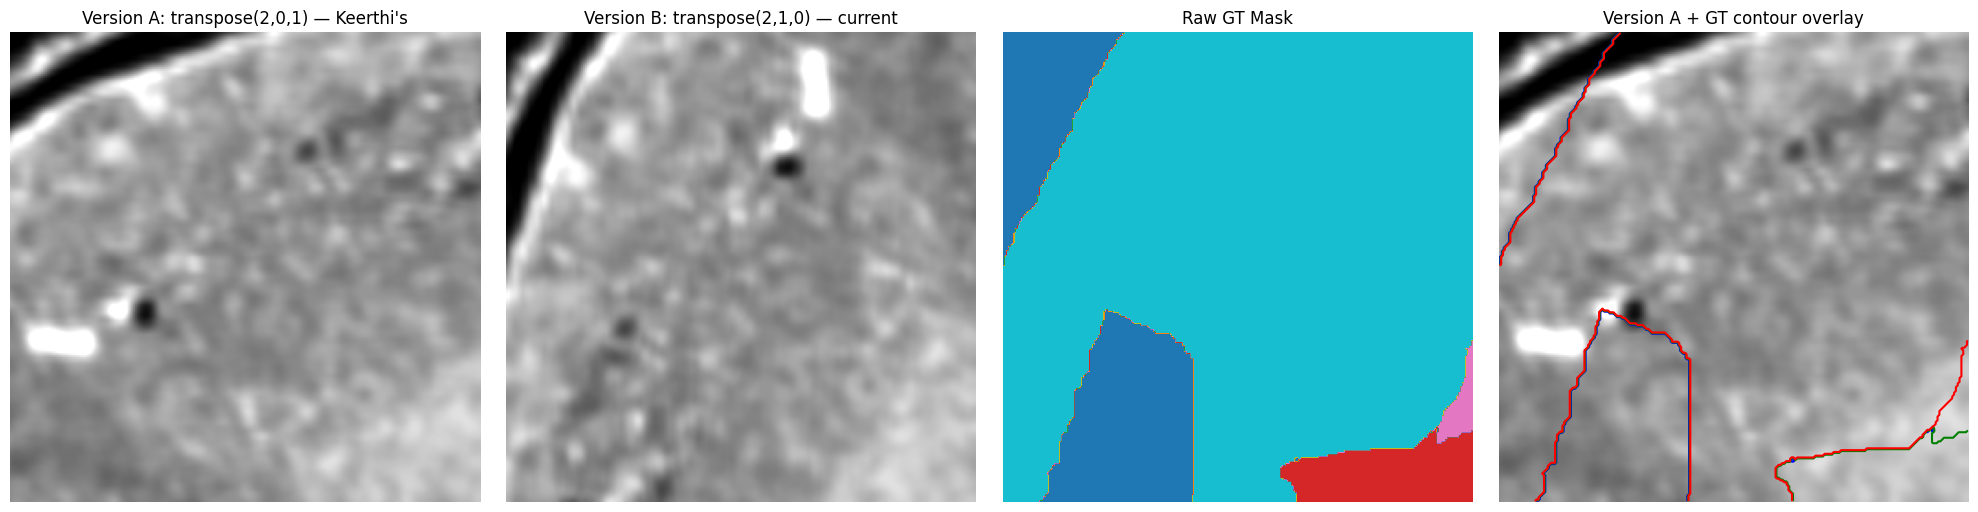

In [3]:
import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

DATA_ROOT = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"
mat_path  = f"{DATA_ROOT}/RS_03948932/CD44/images/patch_000013.mat"
mask_path = f"{DATA_ROOT}/RS_03948932/CD44/masks/patch_000013.png"

with h5py.File(mat_path, 'r') as f:
    raw = f['patch_15_chw'][:]   # (256, 256, 15)

raw_mask = np.array(Image.open(mask_path))
if raw_mask.ndim == 3:
    raw_mask = raw_mask[:, :, 0]

# try BOTH transpositions and compare
version_A = np.transpose(raw, (2, 0, 1))[13]   # PI's suggestion — (C,H,W) → band 14
version_B = np.transpose(raw, (2, 1, 0))[13]   # our current — swaps X/Y

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(version_A, cmap='gray')
axes[0].set_title("Version A: transpose(2,0,1) — Keerthi's")
axes[0].axis('off')

axes[1].imshow(version_B, cmap='gray')
axes[1].set_title("Version B: transpose(2,1,0) — current")
axes[1].axis('off')

axes[2].imshow(raw_mask, cmap='tab10', vmin=0, vmax=3)
axes[2].set_title("Raw GT Mask")
axes[2].axis('off')

# overlay version A with GT contour
axes[3].imshow(version_A, cmap='gray')
axes[3].contour(raw_mask.astype(float), levels=[0.5, 1.5, 2.5], linewidths=1.5, colors=['blue','green','red'])
axes[3].set_title("Version A + GT contour overlay")
axes[3].axis('off')

plt.tight_layout()
plt.savefig("/u/aayyah3/oral-biomarker-segmentation/outputs/orientation_check.png", dpi=150)
plt.show()

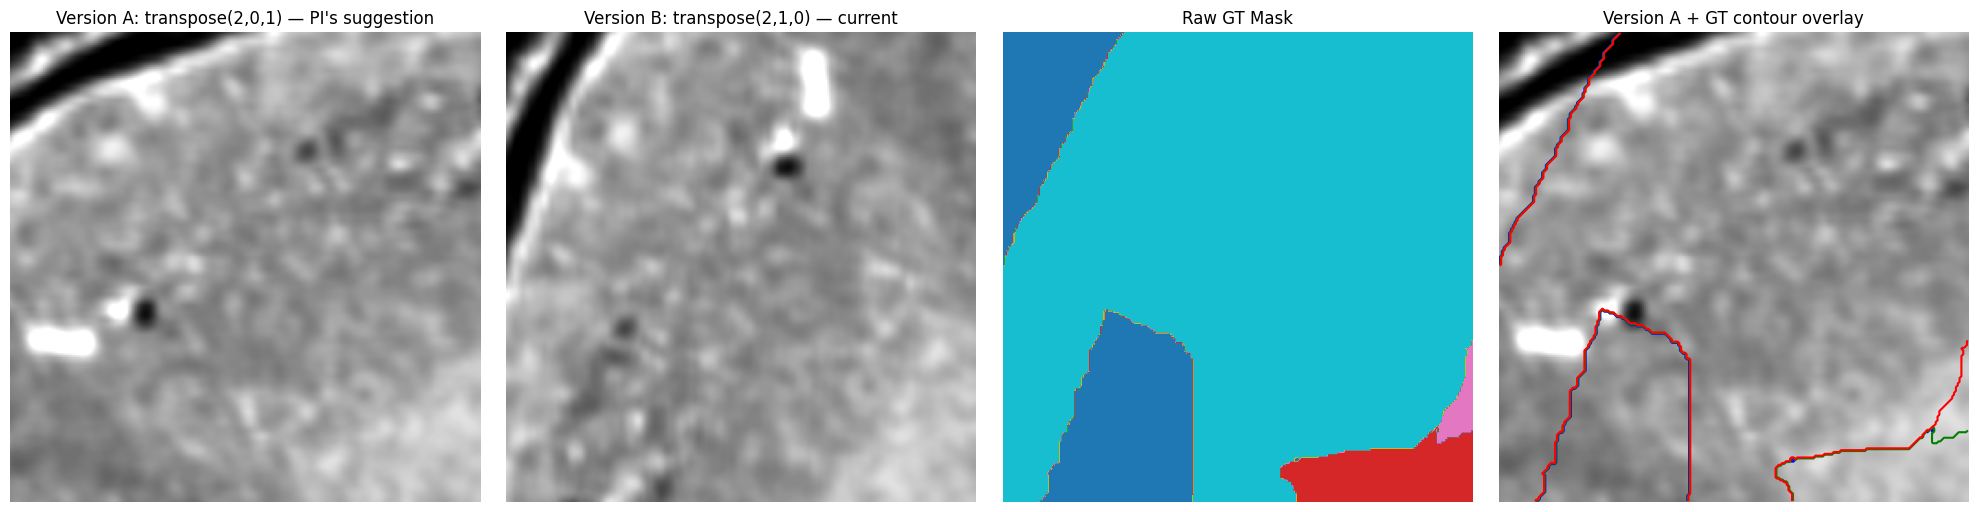

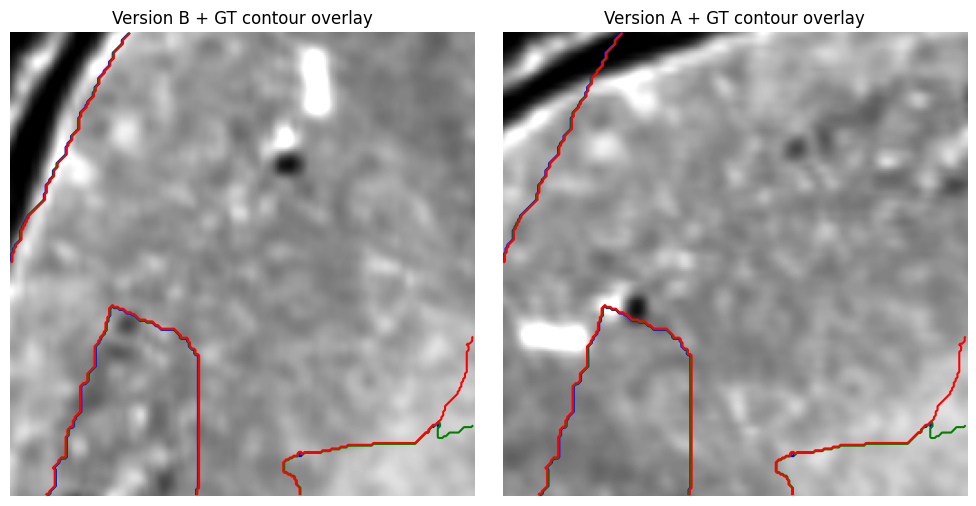

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(version_A, cmap='gray')
axes[0].set_title("Version A: transpose(2,0,1) — PI's suggestion")
axes[0].axis('off')

axes[1].imshow(version_B, cmap='gray')
axes[1].set_title("Version B: transpose(2,1,0) — current")
axes[1].axis('off')

axes[2].imshow(raw_mask, cmap='tab10', vmin=0, vmax=3)
axes[2].set_title("Raw GT Mask")
axes[2].axis('off')

# overlay version A with GT contour
axes[3].imshow(version_A, cmap='gray')
axes[3].contour(raw_mask.astype(float), levels=[0.5, 1.5, 2.5], linewidths=1.5, colors=['blue','green','red'])
axes[3].set_title("Version A + GT contour overlay")
axes[3].axis('off')

plt.tight_layout()
plt.savefig("/u/aayyah3/oral-biomarker-segmentation/outputs/orientation_check_A.png", dpi=150)
plt.show()

# now version B overlay
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))

axes2[0].imshow(version_B, cmap='gray')
axes2[0].contour(raw_mask.astype(float), levels=[0.5, 1.5, 2.5], linewidths=1.5, colors=['blue','green','red'])
axes2[0].set_title("Version B + GT contour overlay")
axes2[0].axis('off')

# side by side comparison
axes2[1].imshow(version_A, cmap='gray')
axes2[1].contour(raw_mask.astype(float), levels=[0.5, 1.5, 2.5], linewidths=1.5, colors=['blue','green','red'])
axes2[1].set_title("Version A + GT contour overlay")
axes2[1].axis('off')

plt.tight_layout()
plt.savefig("/u/aayyah3/oral-biomarker-segmentation/outputs/orientation_check_B.png", dpi=150)
plt.show()

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Model loaded — device: cpu
  Loaded 112 patches from 4 patients
Val patches: 112


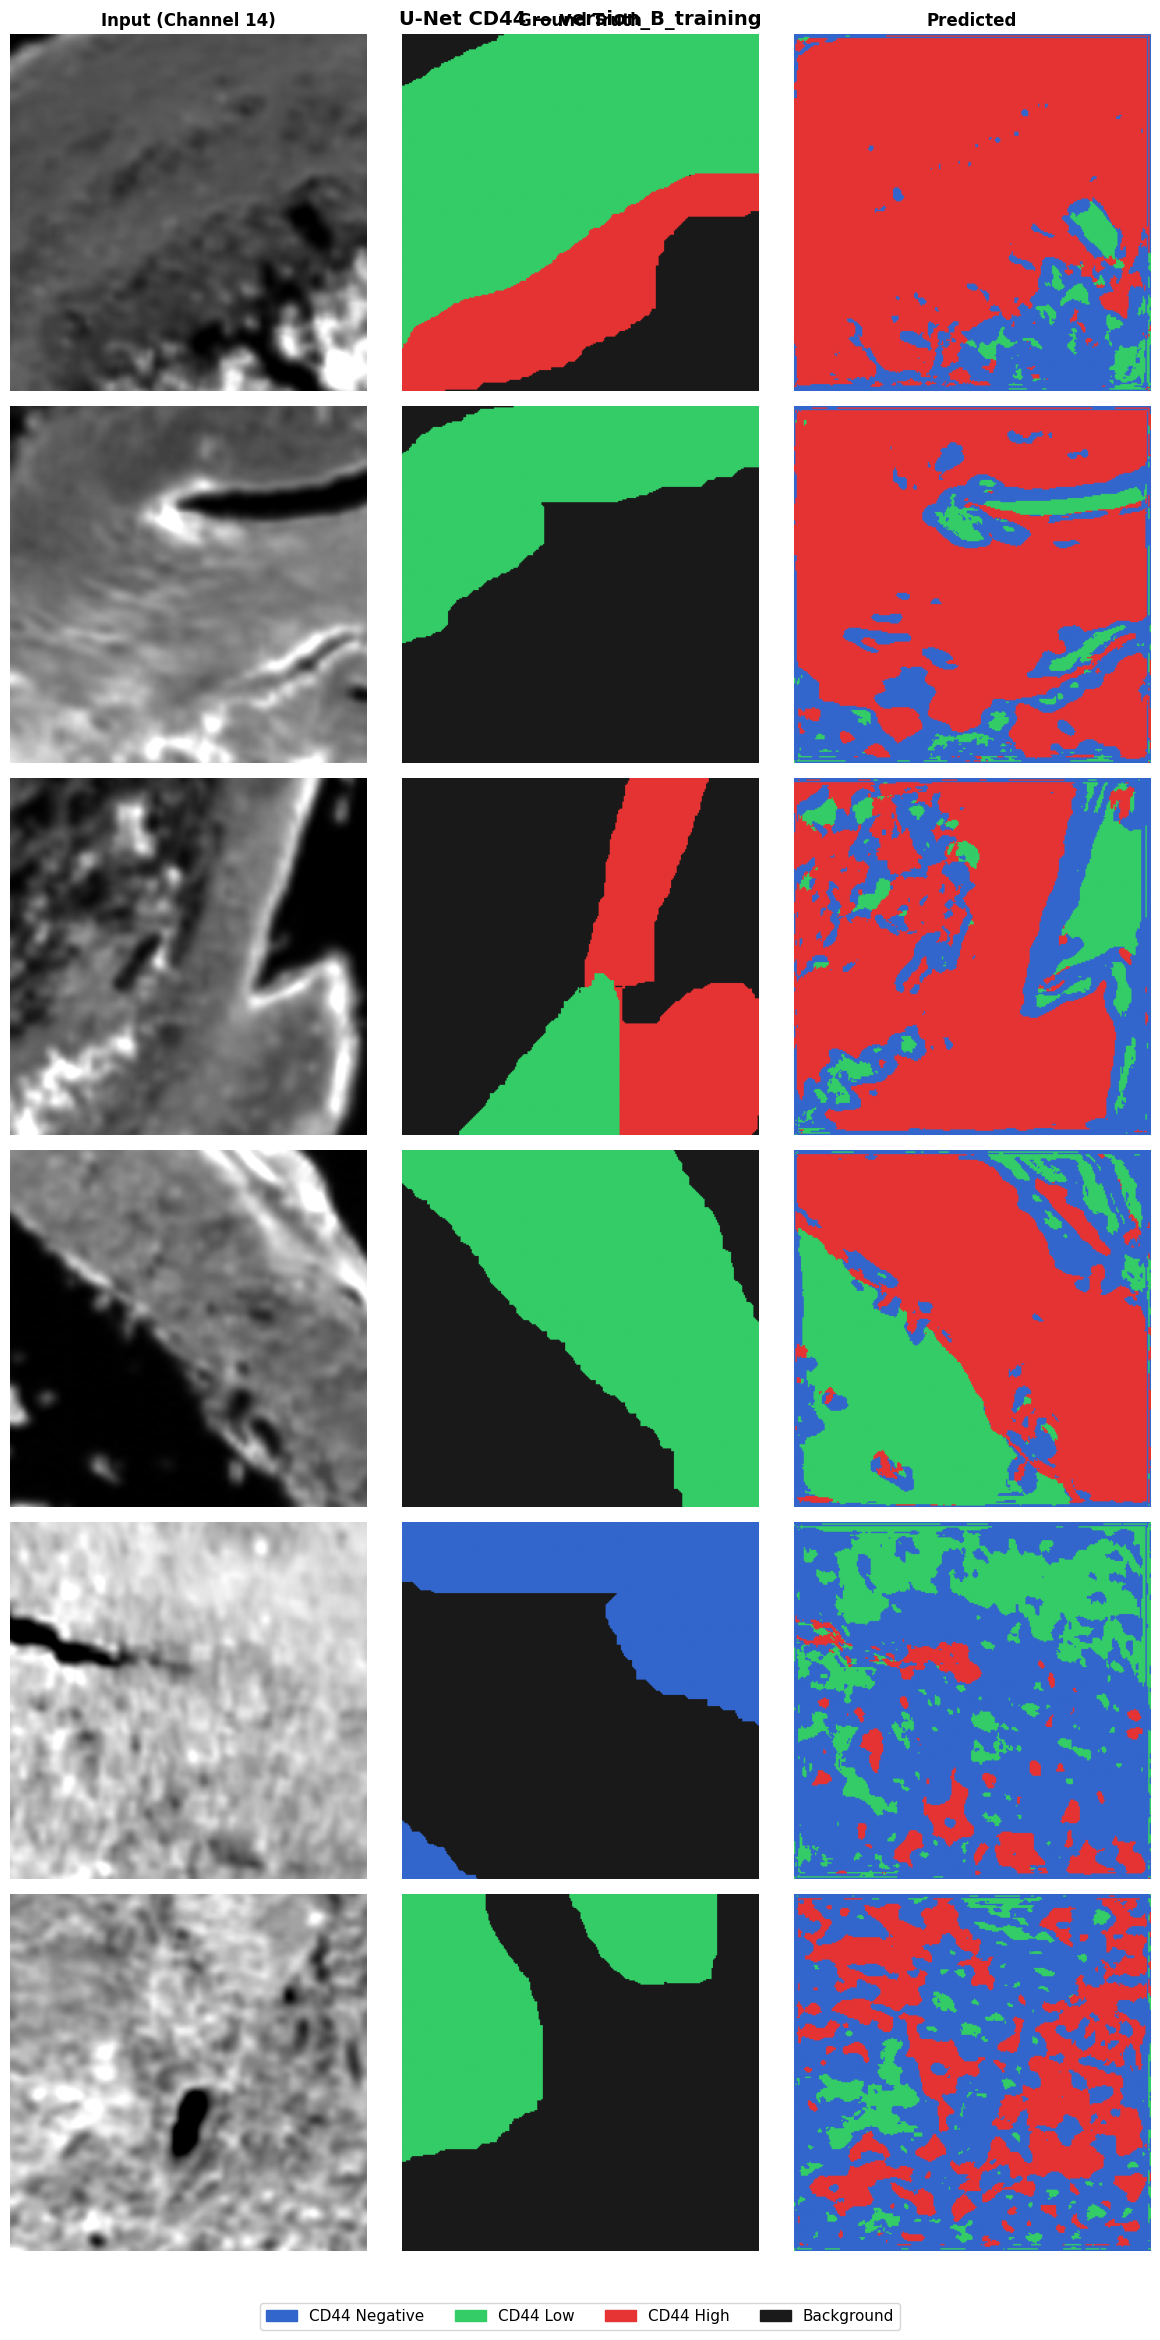

Saved to /u/aayyah3/oral-biomarker-segmentation/outputs/version_A_stable/predictions_versionB.png


In [10]:
%pip install torchvision h5py

import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch

sys.path.append("/u/aayyah3/oral-biomarker-segmentation/src")
from model import UNet
from dataset import CD44Dataset, VAL_PATIENTS

DATA_ROOT    = "/u/aayyah3/oral-biomarker-segmentation/data/Oral_Final_Biomarkers"
NUM_EXAMPLES = 6
MODEL_PATH = "/u/aayyah3/oral-biomarker-segmentation/outputs/version_A_stable/best_dice_model.pth"
SAVE_PATH    = "/u/aayyah3/oral-biomarker-segmentation/outputs/version_A_stable/predictions_versionB.png"

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = UNet(in_channels=1, num_classes=3).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f"Model loaded — device: {device}")

val_ds  = CD44Dataset(DATA_ROOT, VAL_PATIENTS, augment=False)
samples = val_ds.samples
indices = np.linspace(0, len(samples) - 1, NUM_EXAMPLES, dtype=int)
print(f"Val patches: {len(samples)}")

PRED_COLORS = {
    0: [0.2, 0.4, 0.8],
    1: [0.2, 0.8, 0.4],
    2: [0.9, 0.2, 0.2],
}
RAW_COLORS = {
    0: [0.1, 0.1, 0.1],
    1: [0.2, 0.4, 0.8],
    2: [0.2, 0.8, 0.4],
    3: [0.9, 0.2, 0.2],
}

def pred_mask_to_rgb(mask_np):
    rgb = np.ones((*mask_np.shape, 3), dtype=float) * 0.15
    for label, color in PRED_COLORS.items():
        rgb[mask_np == label] = color
    return rgb

def raw_mask_to_rgb(mask_np):
    rgb = np.zeros((*mask_np.shape, 3), dtype=float)
    for label, color in RAW_COLORS.items():
        rgb[mask_np == label] = color
    return rgb

def load_patch(mat_path, mask_path):
    with h5py.File(mat_path, 'r') as f:
        raw = f['patch_15_chw'][:]
    ftir_chw = np.transpose(raw, (2, 1, 0))      # Version B — correct
    img = torch.tensor(ftir_chw.copy(), dtype=torch.float32)
    img = img[13:14, :, :]                        # channel 14 → (1, 256, 256)
    raw_mask = np.array(Image.open(mask_path))
    if raw_mask.ndim == 3:
        raw_mask = raw_mask[:, :, 0]
    return img, raw_mask

fig, axes = plt.subplots(NUM_EXAMPLES, 3, figsize=(12, NUM_EXAMPLES * 4))
fig.suptitle("U-Net CD44 — version_B_training", fontsize=14, fontweight='bold')

col_titles = ["Input (Channel 14)", "Ground Truth", "Predicted"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

for row, idx in enumerate(indices):
    mat_path, mask_path = samples[idx]
    img, raw_mask = load_patch(mat_path, mask_path)

    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))
        pred   = logits.argmax(dim=1).squeeze(0).cpu().numpy()

    img_np = img.squeeze(0).numpy()

    axes[row, 0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(raw_mask_to_rgb(raw_mask))
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred_mask_to_rgb(pred))
    axes[row, 2].axis('off')

legend_patches = [
    mpatches.Patch(color=PRED_COLORS[0], label='CD44 Negative'),
    mpatches.Patch(color=PRED_COLORS[1], label='CD44 Low'),
    mpatches.Patch(color=PRED_COLORS[2], label='CD44 High'),
    mpatches.Patch(color=[0.1, 0.1, 0.1], label='Background'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=11,
           bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {SAVE_PATH}")